In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:

# ── Configuración ──────────────────────────────────────────
DATA_PATH = r"data/raw/huracan_banfield_raw.csv"  
SEPARATOR = ","                  
ENCODING  = "utf-8"              
# ───────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding=ENCODING)
print(f"✅ Dataset cargado — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")


✅ Dataset cargado — Filas: 32 | Columnas: 21


# LIMPIEZA

In [3]:
# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
# Verificamos si hay algún nulo en toda la tabla
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    # Sino mostramos tabla filtrada de nulos
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
0,Bruno Sepúlveda,9,AR,FW,33-310,71,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0
1,Federico Anselmo,30,AR,FW,32-098,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Tiziano Perrotta,17,AR,FW,19-241,90,0,0,0,0,1,0,0,0,0,0,3,0,2,0,0
3,Lautaro Gómez,10,AR,LM,22-350,71,0,0,0,0,1,1,0,0,1,1,0,2,0,1,0
4,Federico Medina,18,AR,MF,22-158,19,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0



--- Últimas 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
27,Leandro Lescano,19,AR,MF,23-143,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
28,Máximo Palazzo,35,AR,CB,21-048,90,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0
29,Hugo Nervo,21,AR,CB,35-199,90,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
30,Lucas Blondel,2,CH,RB,29-313,90,0,0,0,0,2,1,0,0,2,2,0,2,2,1,0
31,Hernán Galíndez,1,ECU,GK,39-116,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Filas: 32 | Columnas: 21

--- Info general ---
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Player  32 non-null     str  
 1   #       32 non-null     int64
 2   Nation  32 non-null     str  
 3   Pos     32 non-null     str  
 4   Age     32 non-null     str  
 5   Min     32 non-null     int64
 6   Gls     32 non-null     int64
 7   Ast     32 non-null     int64
 8   PK      32 non-null     int64
 9   PKatt   32 non-null     int64
 10  Sh      32 non-null     int64
 11  SoT     32 non-null     int64
 12  CrdY    32 non-null     int64
 13  CrdR    32 non-null     int64
 14  Fls     32 non-null     int64
 15  Fld     32 non-null     int64
 16  Off     32 non-null     int64
 17  Crs     32 non-null     int64
 18  TklW    32 non-null     int64
 19  Int     32 non-null     int64
 20  OG      32 non-null     int64
dtypes: int64(17), str(4)
memory usage: 5.4 KB

--- Nulo

,#,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,16.50,61.88,0.03,0.03,0.00,0.00,0.81,0.38,0.12,0.00,0.72,0.69,0.16,0.88,0.69,0.62,0.00
std,10.93,33.53,0.18,0.18,0.00,0.00,1.38,0.71,0.34,0.00,1.02,0.86,0.63,1.84,1.03,0.91,0.00
min,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.75,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,17.00,79.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00
max,40.00,90.00,1.00,1.00,0.00,0.00,6.00,3.00,1.00,0.00,3.00,3.00,3.00,9.00,4.00,4.00,0.00


In [4]:
# Separar Age en años y días
df_raw[['edad_años', 'edad_dias']] = df_raw['Age'].str.split('-', expand=True).astype(int)

# Verificar
print(f"NaN en edad_años: {df_raw['edad_años'].isnull().sum()}")
print(f"NaN en edad_dias: {df_raw['edad_dias'].isnull().sum()}")
display(df_raw[['Age', 'edad_años', 'edad_dias']].head(5))

# Eliminar columna original
df_raw = df_raw.drop(columns=['Age'])

NaN en edad_años: 0
NaN en edad_dias: 0


,Age,edad_años,edad_dias
0,33-310,33,310
1,32-098,32,98
2,19-241,19,241
3,22-350,22,350
4,22-158,22,158


In [5]:
# Ver si el índice tiene huecos
print(f'Índice antes del reset: {df_raw.index.tolist()[:10]}...')

# Resetear
df_raw = df_raw.reset_index(drop=True)

# Verificar
print(f'Índice después del reset: {df_raw.index.tolist()[:10]}...')
print(f'Filas finales: {df_raw.shape[0]}')

Índice antes del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Índice después del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Filas finales: 32


In [6]:
print('=' * 50)
print('REPORTE FINAL DE CALIDAD')
print('=' * 50)
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 50)

REPORTE FINAL DE CALIDAD
Filas finales:      32
Columnas:           22
Duplicados:         0
Nulos totales:      0


In [7]:
# Renombrar a df_clean antes de exportar
df_clean = df_raw.copy()

# Exportar
nombre_salida = 'data/clean/huracan_banfield_clean.csv'    
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'Dataset exportado: {nombre_salida}')
print(f'Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

Dataset exportado: data/clean/huracan_banfield_clean.csv
Filas: 32 | Columnas: 22


# EDA

In [8]:
# ── Diccionarios de traducción FBref ─────────────────────────────────────
# Reutilizable en cualquier análisis de FBref
# Fuente: glosario oficial FBref

COLUMNAS_ES = {
    'Player':  'Jugador',
    '#':       'Camiseta',
    'Pos':     'Posición',
    'Age':     'Edad',
    'Min':     'Minutos',
    'Gls':     'Goles',
    'Ast':     'Asistencias',
    'PK':      'Penales convertidos',
    'PKatt':   'Penales intentados',
    'Sh':      'Tiros totales',
    'SoT':     'Tiros al arco',
    'CrdY':    'Tarjetas amarillas',
    'CrdR':    'Tarjetas rojas',
    'Fls':     'Faltas cometidas',
    'Fld':     'Faltas recibidas',
    'Off':     'Fueras de juego',
    'Crs':     'Centros',
    'TklW':    'Entradas ganadas',
    'Int':     'Intercepciones',
    'OG':      'Goles en contra',
    'PKwon':   'Penales ganados',
    'PKcon':   'Penales concedidos',
}

POSICIONES_ES = {
    'GK':   'Arquero',
    'DF':   'Defensor',
    'MF':   'Mediocampista',
    'FW':   'Delantero',
    'FB':   'Lateral',
    'LB':   'Lateral izquierdo',
    'RB':   'Lateral derecho',
    'CB':   'Defensor central',
    'DM':   'Mediocampista defensivo',
    'CM':   'Mediocampista central',
    'LM':   'Mediocampista izquierdo',
    'RM':   'Mediocampista derecho',
    'WM':   'Mediocampista amplio',
    'LW':   'Extremo izquierdo',
    'RW':   'Extremo derecho',
    'AM':   'Mediocampista ofensivo',
}


def traducir_columnas(df):
    """
    Renombra las columnas de un DataFrame de FBref al español.
    Solo traduce las columnas que existen — no falla si faltan columnas.
    """
    columnas_presentes = {k: v for k, v in COLUMNAS_ES.items() if k in df.columns}
    df = df.rename(columns=columnas_presentes)
    print(f"Columnas traducidas: {len(columnas_presentes)}")
    return df


def traducir_posiciones(df, columna='Posición'):
    """
    Traduce las abreviaturas de posición al español.
    Maneja posiciones combinadas como 'DF,FW' o 'FW,MF'.

    Parámetros:
        columna : nombre de la columna de posición (después de traducir columnas)
    """
    if columna not in df.columns:
        print(f"Columna '{columna}' no encontrada — verificá que ya tradujiste las columnas")
        return df

    def traducir_pos(valor):
        if pd.isna(valor):
            return valor
        # Manejar posiciones combinadas (ej: 'DF,FW', 'FW,MF')
        partes = str(valor).split(',')
        traducidas = [POSICIONES_ES.get(p.strip(), p.strip()) for p in partes]
        return ' / '.join(traducidas)

    df[columna] = df[columna].apply(traducir_pos)
    return df


# ── Uso ───────────────────────────────────────────────────────────────────
df_clean = traducir_columnas(df_clean)
df_clean = traducir_posiciones(df_clean)
display(df_clean.head())


Columnas traducidas: 19


,Jugador,Camiseta,Nation,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,edad_años,edad_dias
0,Bruno Sepúlveda,9,AR,Delantero,71,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,33,310
1,Federico Anselmo,30,AR,Delantero,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,98
2,Tiziano Perrotta,17,AR,Delantero,90,0,0,0,0,1,0,0,0,0,0,3,0,2,0,0,19,241
3,Lautaro Gómez,10,AR,Mediocampista izquierdo,71,0,0,0,0,1,1,0,0,1,1,0,2,0,1,0,22,350
4,Federico Medina,18,AR,Mediocampista,19,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0,22,158


In [10]:
df_clean

,Jugador,Camiseta,Nation,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,edad_años,edad_dias
0,Bruno Sepúlveda,9,AR,Delantero,71,0,0,0,0,0,0,0,0,1,0,2,0,0,0,0,33,310
1,Federico Anselmo,30,AR,Delantero,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32,98
2,Tiziano Perrotta,17,AR,Delantero,90,0,0,0,0,1,0,0,0,0,0,3,0,2,0,0,19,241
3,Lautaro Gómez,10,AR,Mediocampista izquierdo,71,0,0,0,0,1,1,0,0,1,1,0,2,0,1,0,22,350
4,Federico Medina,18,AR,Mediocampista,19,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0,22,158
5,Ignacio Pais,35,AR,Mediocampista central,78,0,0,0,0,1,0,0,0,3,0,0,1,2,1,0,26,55
6,Neyder Moreno,33,CO,Mediocampista,12,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,29,165
7,Santiago Esquivel,5,AR,Mediocampista central,57,0,0,0,0,0,0,1,0,2,1,0,0,1,1,0,22,203
8,Lautaro Villegas,21,AR,Mediocampista,33,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,22,206
9,David Zalazar,40,AR,Mediocampista derecho,57,0,0,0,0,1,0,1,0,0,1,0,9,1,1,0,24,76


In [11]:
# Tipos de datos y nulos
df_clean.info()
# Estadísticas descriptivas de variables numéricas
df_clean.describe()
# Primeras filas
df_clean.head()
# Nulos y porcentaje
nulos = pd.DataFrame({
    'Nulos': df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])
# Duplicados
print(f'Filas duplicadas: {df_clean.duplicated().sum()}')
# Valores únicos por columna
df_clean.nunique().sort_values()


<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Jugador              32 non-null     str  
 1   Camiseta             32 non-null     int64
 2   Nation               32 non-null     str  
 3   Posición             32 non-null     str  
 4   Minutos              32 non-null     int64
 5   Goles                32 non-null     int64
 6   Asistencias          32 non-null     int64
 7   Penales convertidos  32 non-null     int64
 8   Penales intentados   32 non-null     int64
 9   Tiros totales        32 non-null     int64
 10  Tiros al arco        32 non-null     int64
 11  Tarjetas amarillas   32 non-null     int64
 12  Tarjetas rojas       32 non-null     int64
 13  Faltas cometidas     32 non-null     int64
 14  Faltas recibidas     32 non-null     int64
 15  Fueras de juego      32 non-null     int64
 16  Centros              32 non-null     in

,Nulos,Porcentaje


Filas duplicadas: 0


Penales convertidos     1
Penales intentados      1
Tarjetas rojas          1
Goles en contra         1
Asistencias             2
Tarjetas amarillas      2
Goles                   2
Fueras de juego         3
Faltas recibidas        4
Tiros al arco           4
Intercepciones          4
Faltas cometidas        4
Centros                 5
Entradas ganadas        5
Tiros totales           5
Nation                  8
Posición               11
Minutos                13
edad_años              18
Camiseta               22
Jugador                32
edad_dias              32
dtype: int64

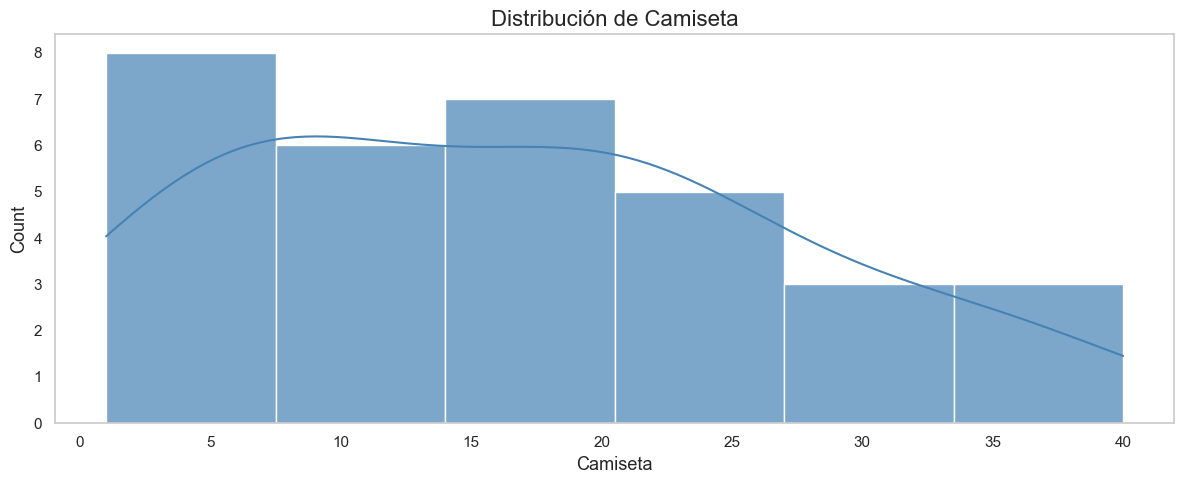

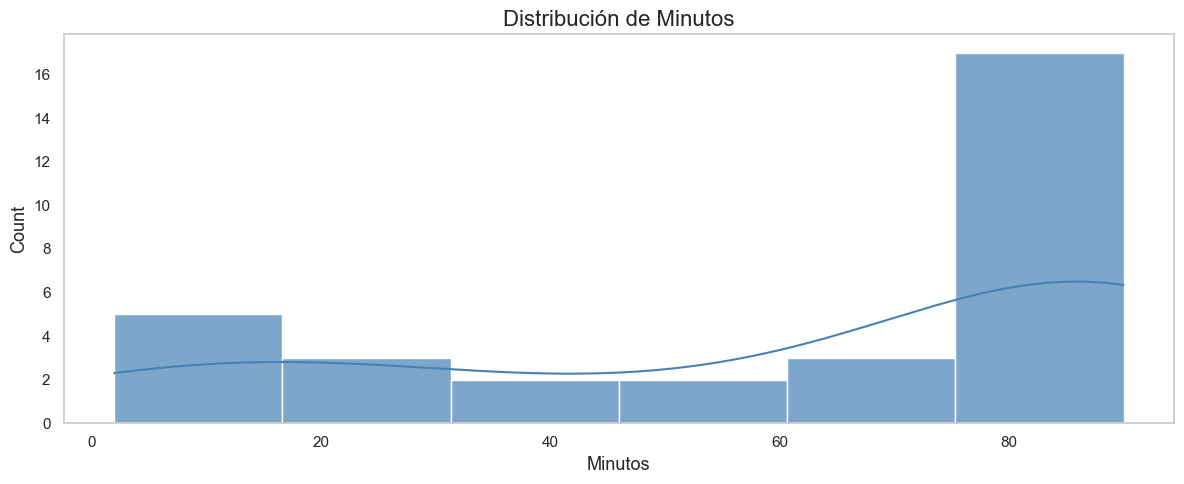

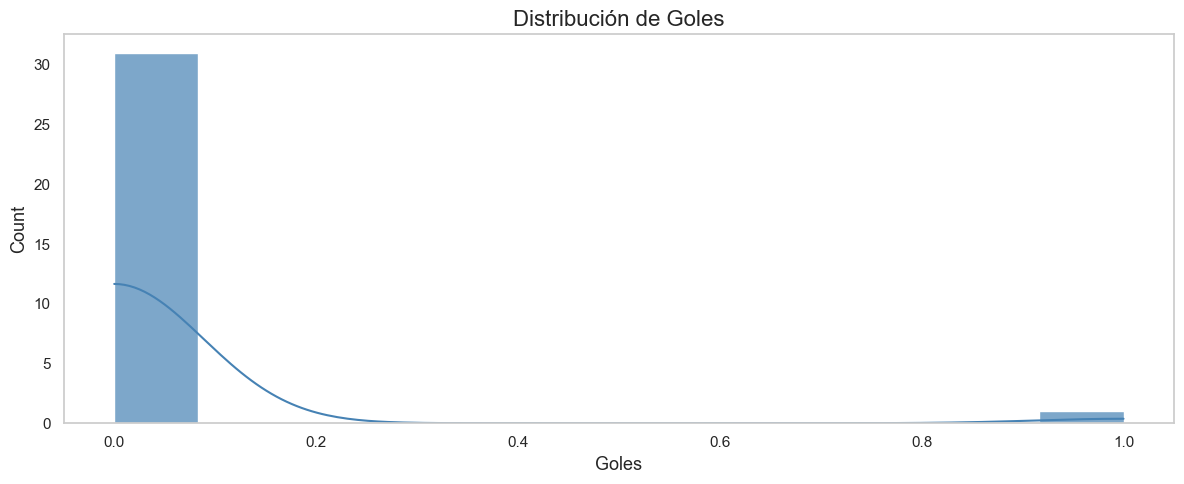

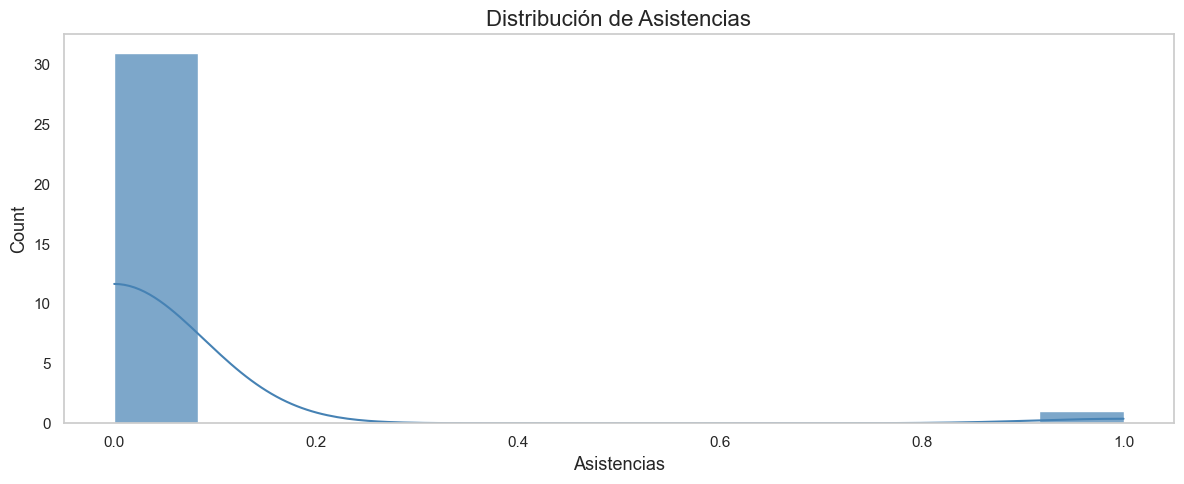

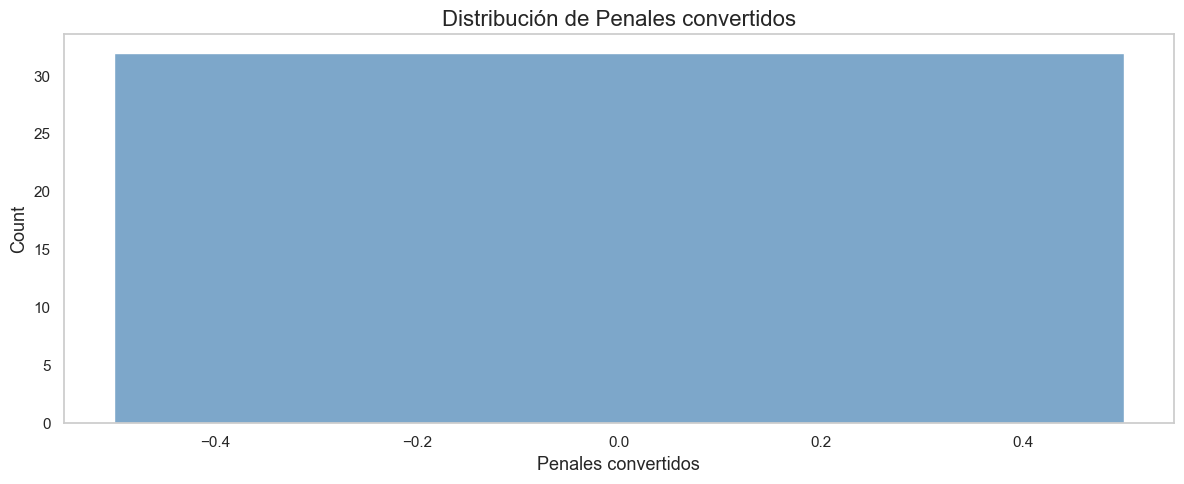

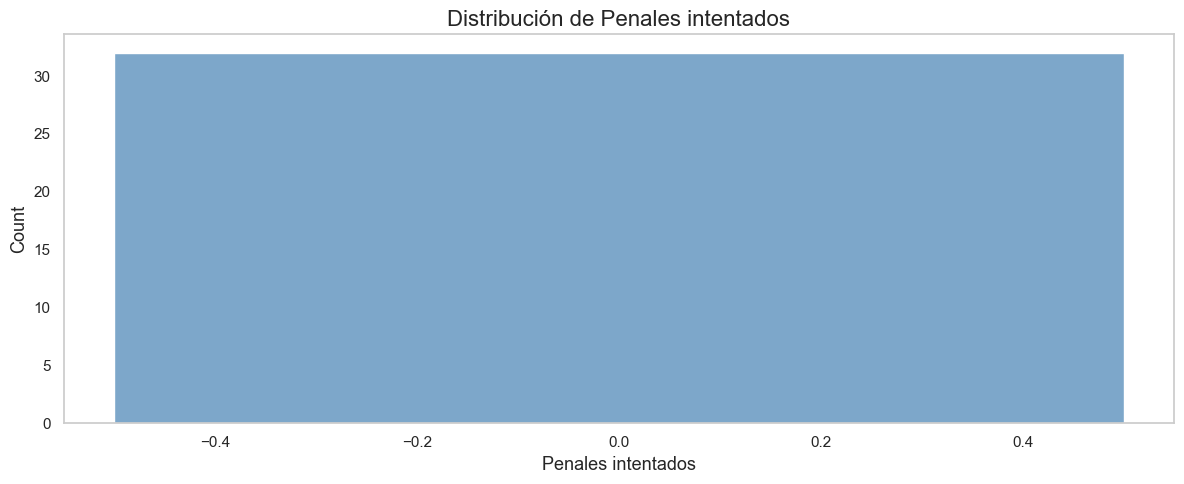

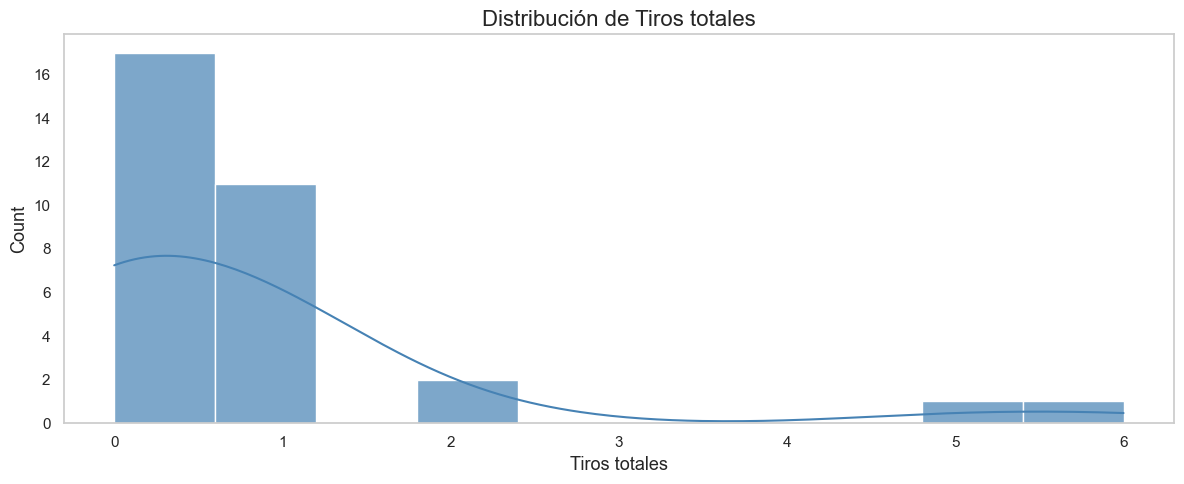

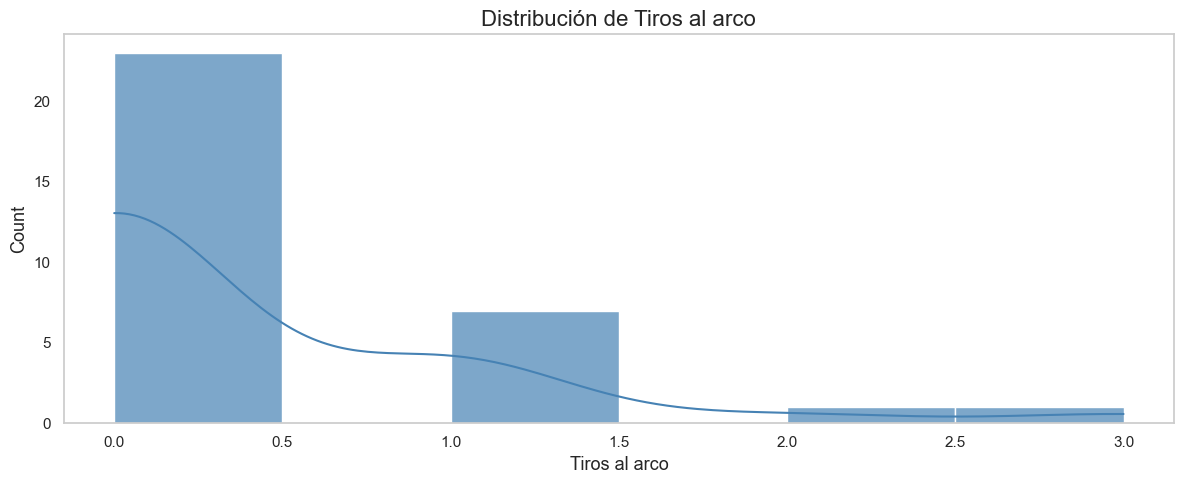

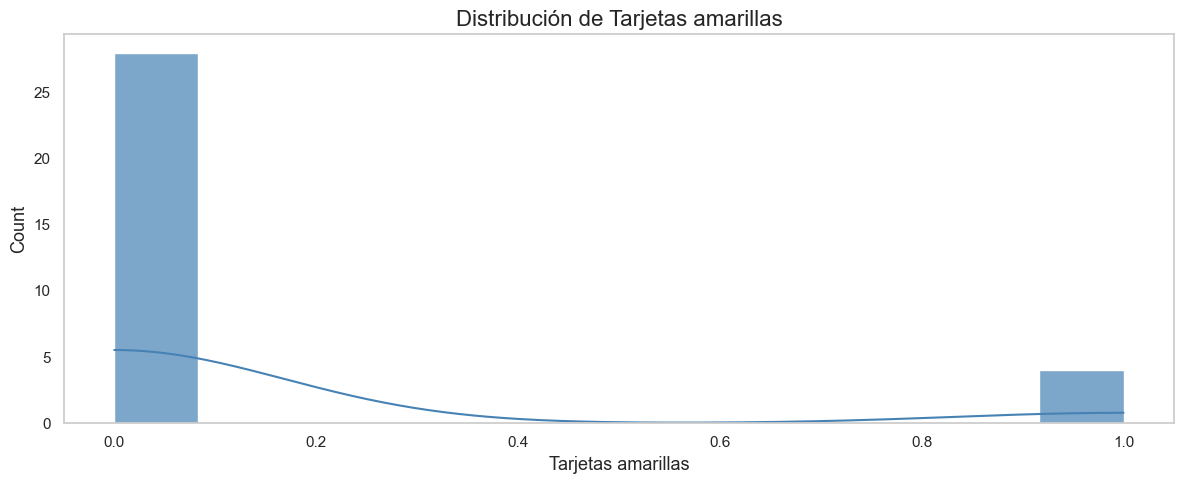

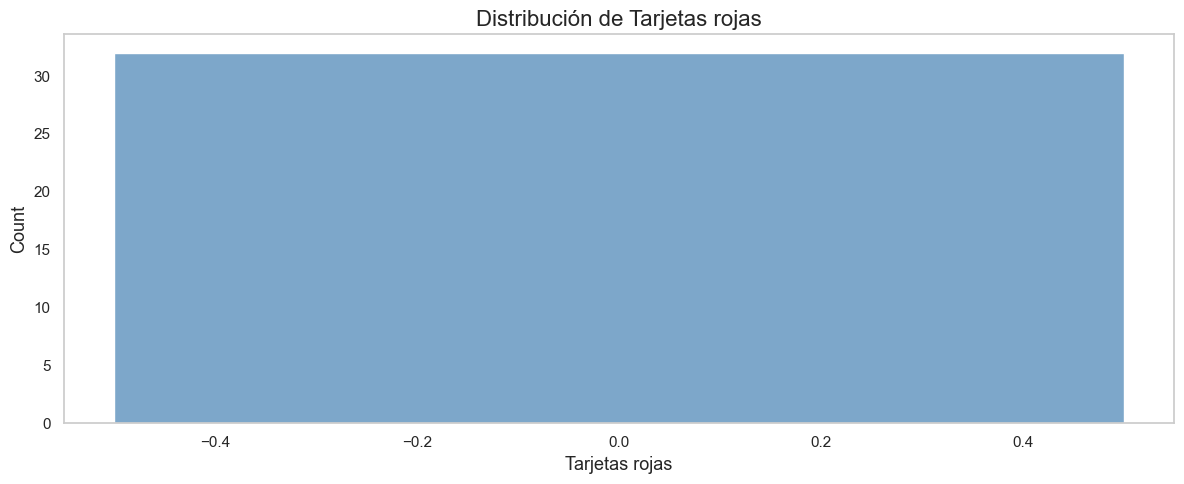

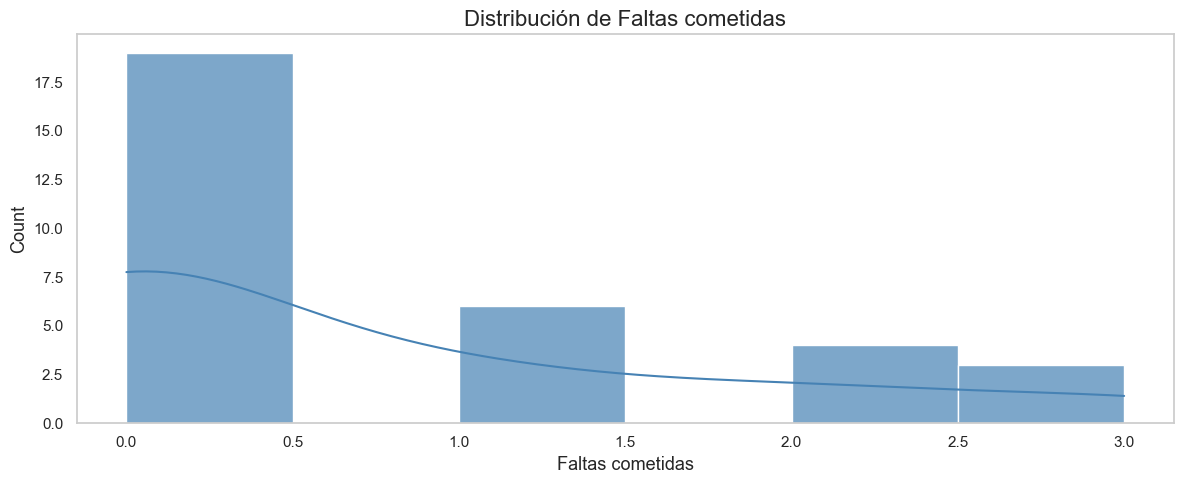

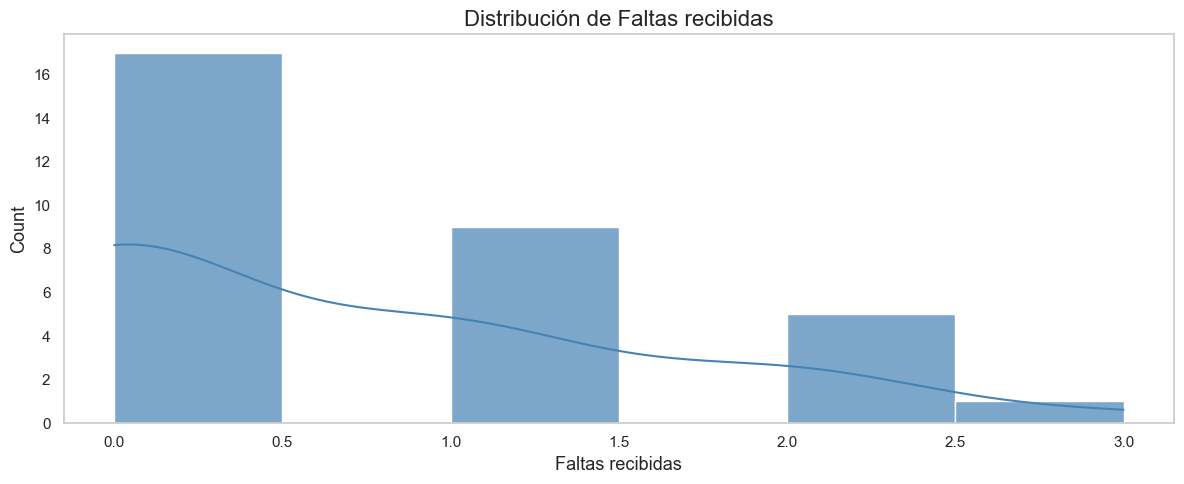

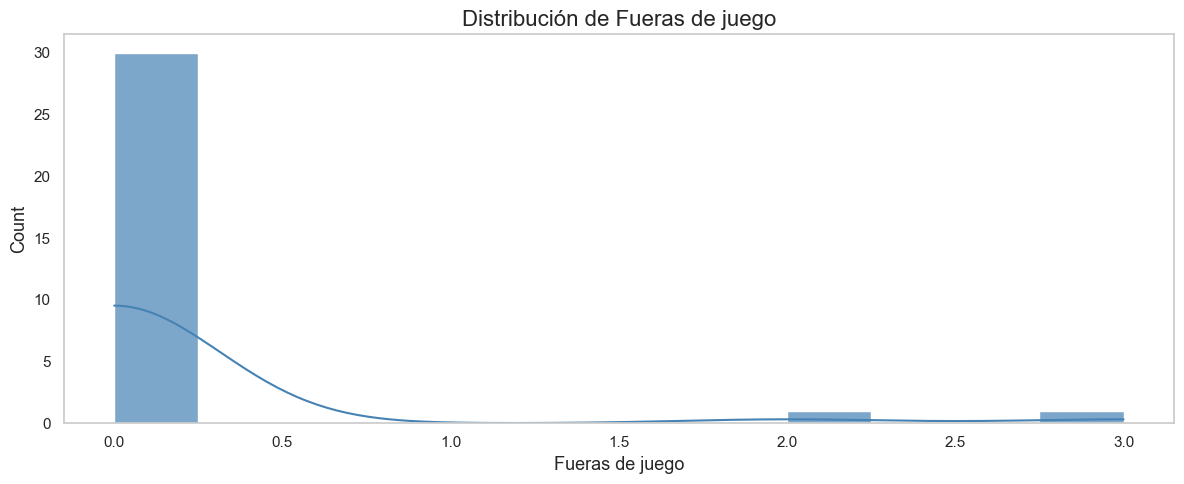

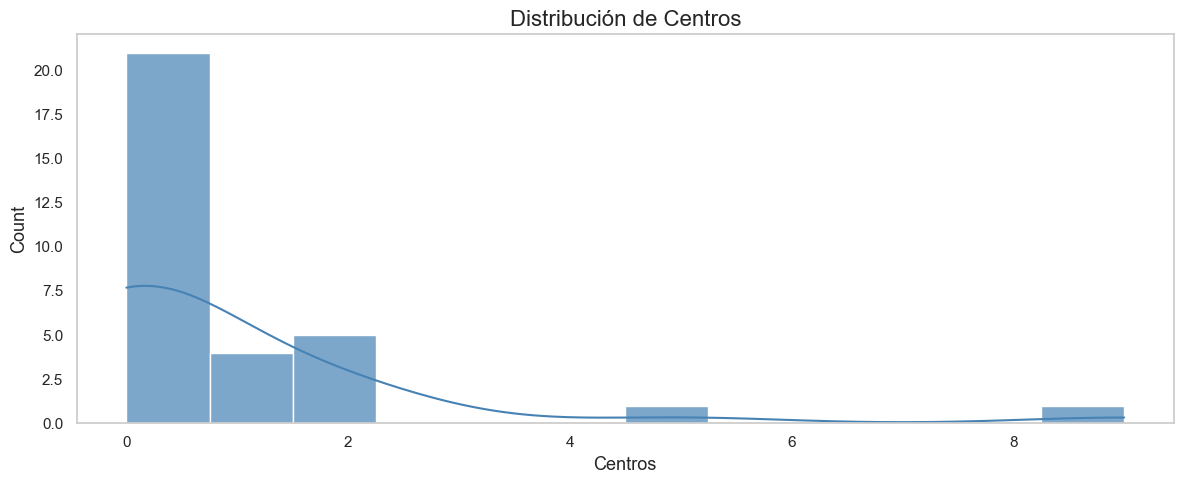

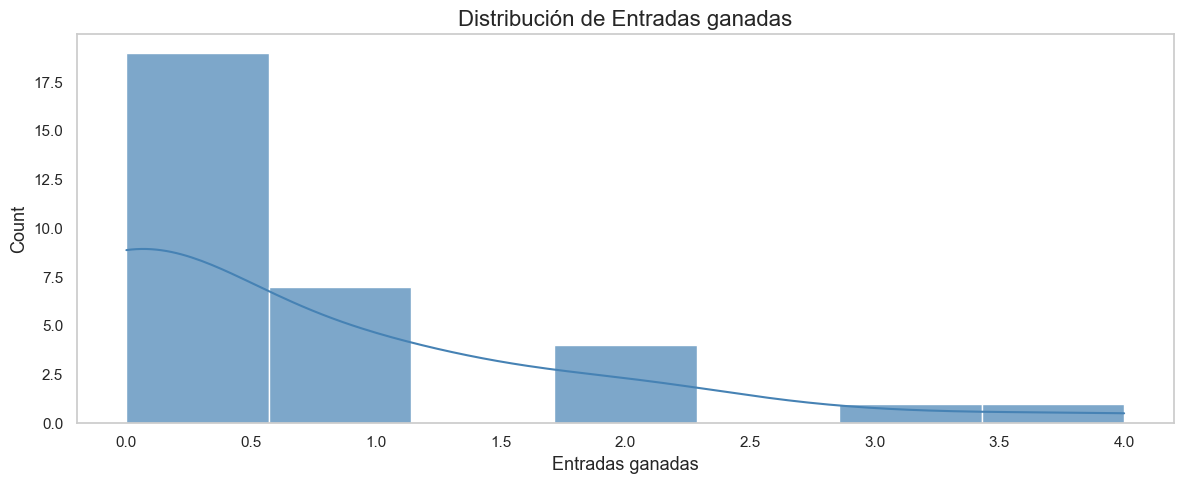

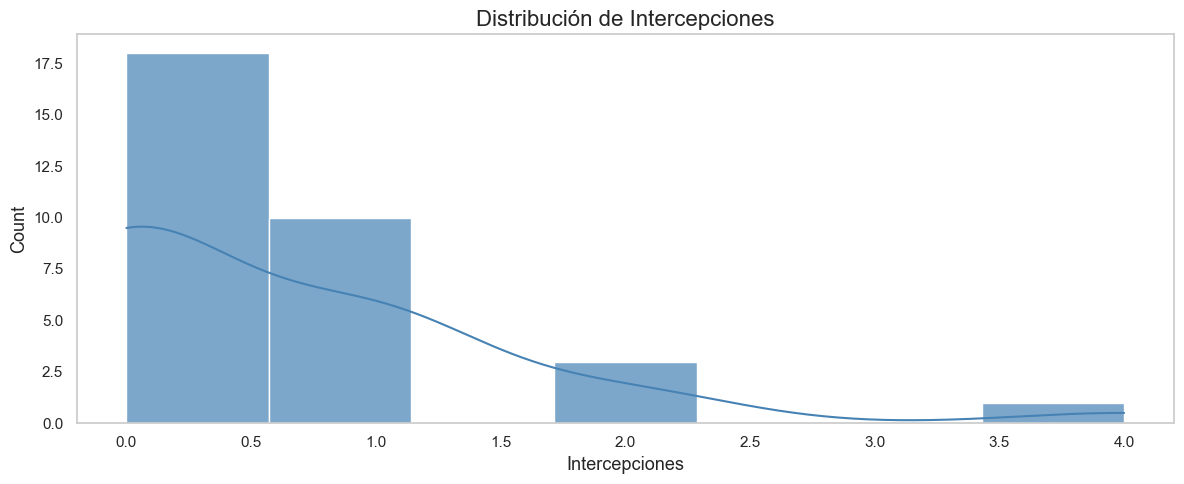

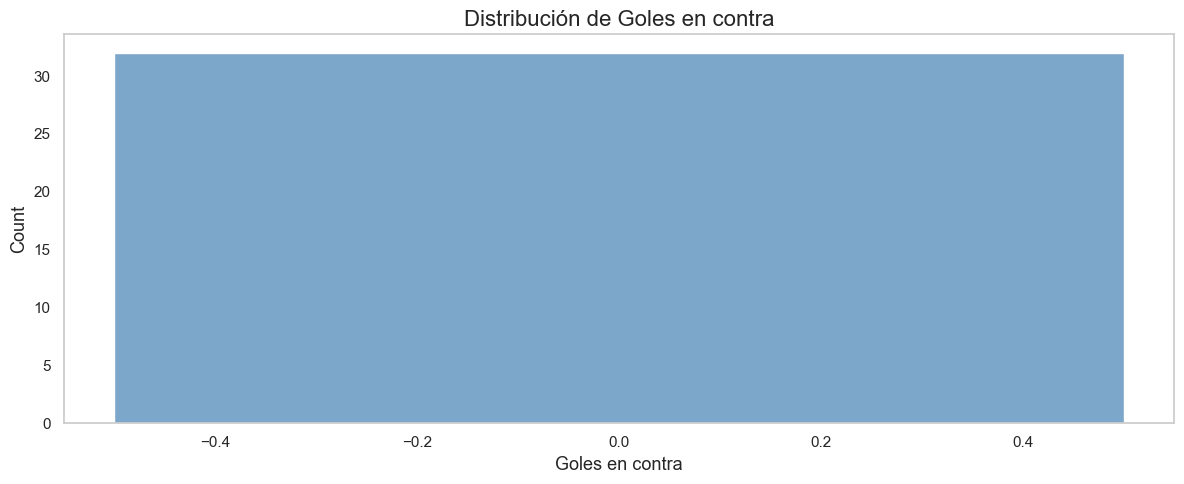

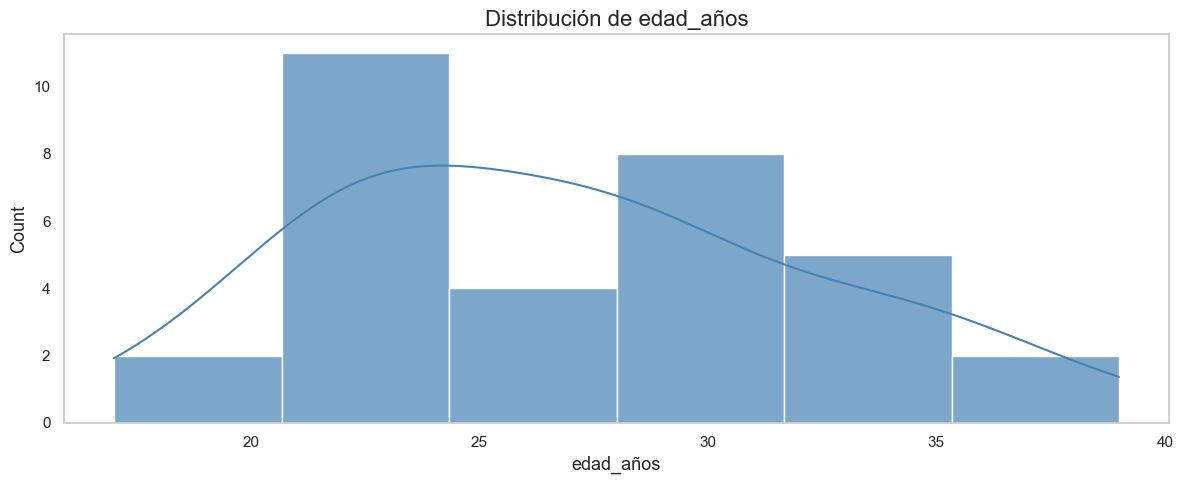

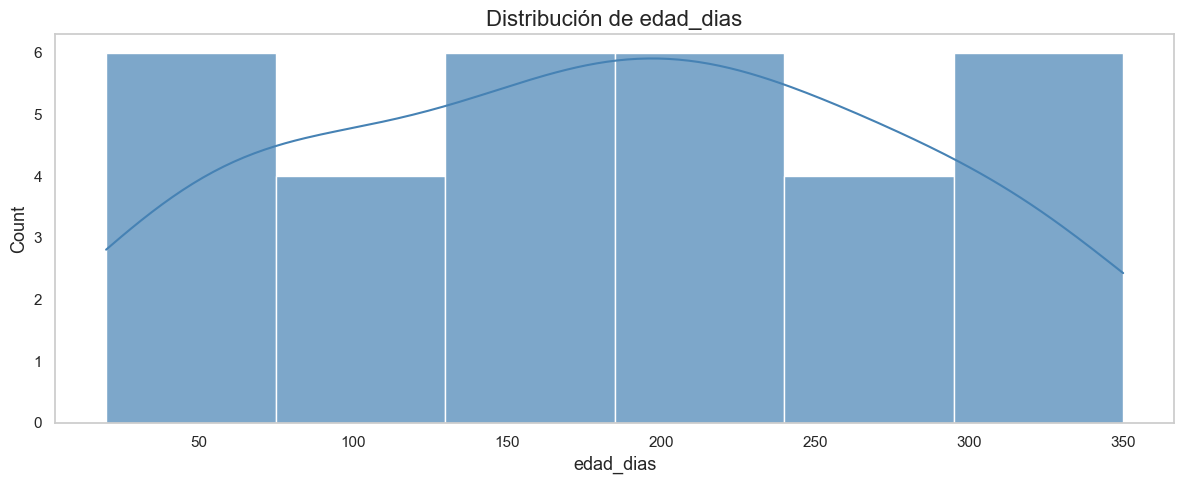

In [14]:
columnas_numericas = df_clean.select_dtypes(include='number').columns.tolist()

for col in columnas_numericas:
    plt.figure(figsize=(12, 5))
    sns.histplot(data=df_clean, x=col, kde=True, color='steelblue', alpha=0.7)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

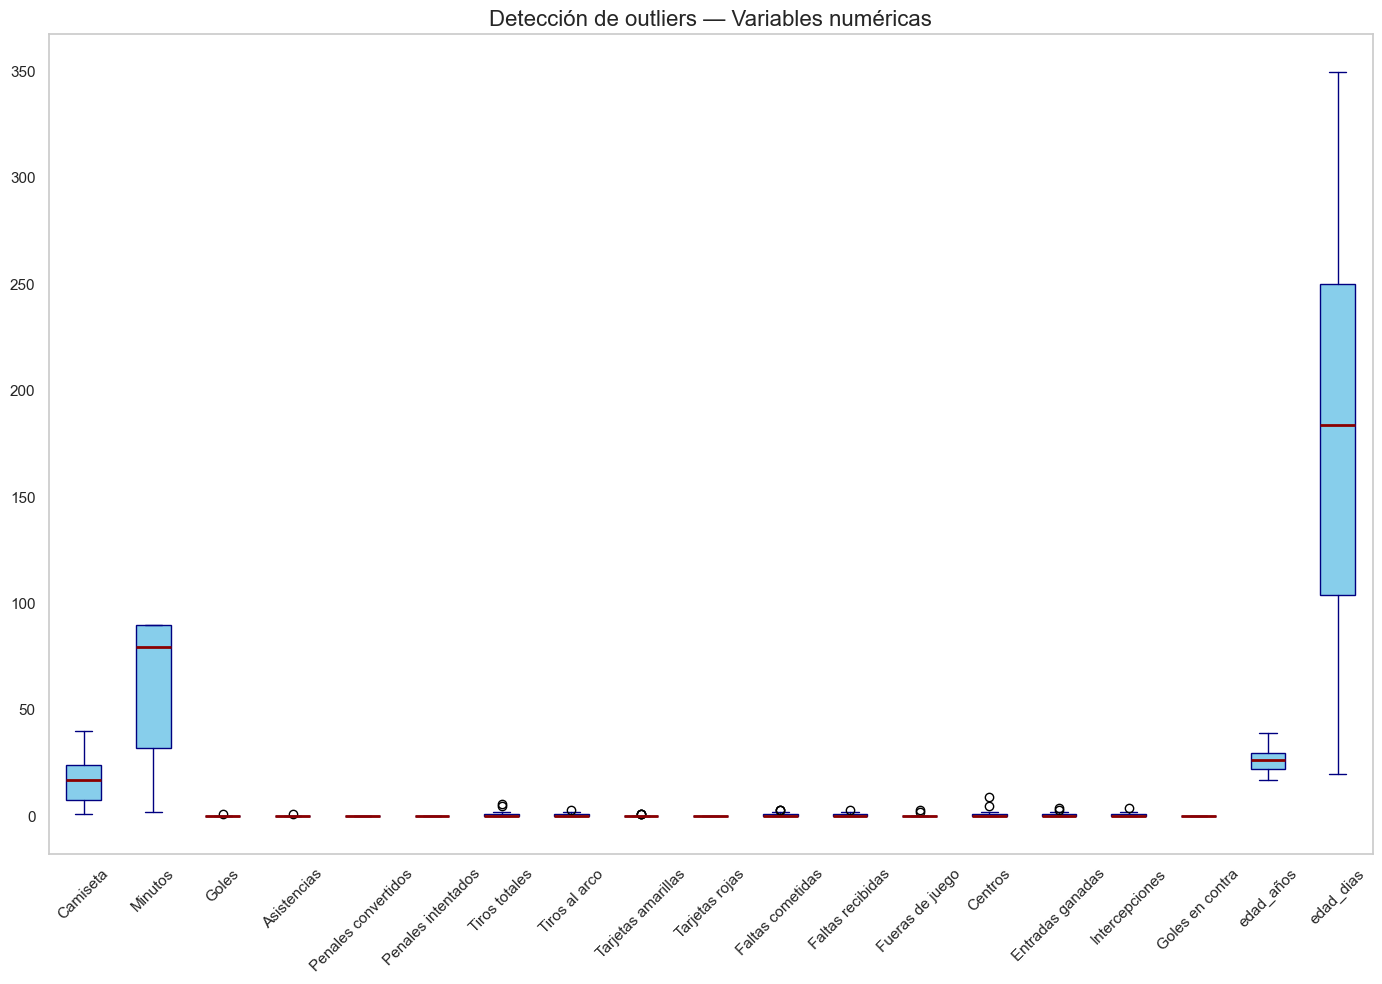

In [13]:
# Boxplot de todas las variables numéricas
plt.figure(figsize=(14, 10))
df_clean[columnas_numericas].boxplot(
    grid=False,                
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='navy'),   
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    medianprops=dict(color='darkred', linewidth=2) 
)         
plt.title('Detección de outliers — Variables numéricas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()